In [1]:
!pip install qiskit
!pip install qiskit-aer
!pip install qiskit-ibm-runtime


  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 15.7 MB/s eta 0:00:00
Using cached requests-2.32.5-py3-none-any.whl (64 kB)
Using cached urllib3-2.5.0-py3-none-any.whl (129 kB)
   ---------------------------------------- 0.0/540.8 kB ? eta -:--:--
   --------------------------------------- 540.8/540.8 kB 17.5 MB/s eta 0:00:00

  Attempting uninstall: urllib3

    Found existing installation: urllib3 2.3.0

    Uninstalling urllib3-2.3.0:

      Successfully uninstalled urllib3-2.3.0

   ---------------------------------------- 0/8 [urllib3]
  Attempting uninstall: requests
   ---------------------------------------- 0/8 [urllib3]
    Found existing installation: requests 2.32.3
   ---------------------------------------- 0/8 [urllib3]
    Uninstalling requests-2.32.3:
   ------------

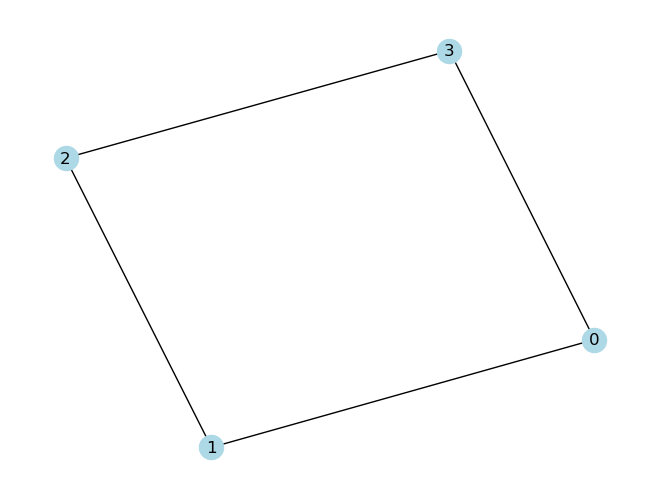

Parámetros óptimos: [1.8836554  2.72178328]
Valor final del costo: 2.97265625
Tiempo total de ejecución: 5.460964918136597 segundos


In [3]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from scipy.optimize import minimize
import time

graph = nx.Graph([(0,1),(1,2),(2,3),(3,0)])
nx.draw(graph, with_labels=True, node_color='lightblue')
plt.show()

n_qubits = len(graph.nodes)

# --- Construir circuito QAOA ---
def qaoa_circuit(params):
    gamma, beta = params
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))  # estado inicial
    # capa de costo
    for i,j in graph.edges:
        qc.cx(i,j)
        qc.rz(2*gamma,j)
        qc.cx(i,j)
    # capa de mixer
    qc.rx(2*beta, range(n_qubits))
    qc.measure_all()
    return qc

# --- Función de costo usando AerSimulator ---
simulator = AerSimulator()

def cost_function(params):
    qc = qaoa_circuit(params)
    t_qc = transpile(qc, simulator)
    job = simulator.run(t_qc, shots=1024)
    result = job.result()
    counts = result.get_counts()
    cost = 0
    for bitstring, c in counts.items():
        z = np.array([1 if b=='0' else -1 for b in bitstring])
        s = sum(0.5*(1 - z[i]*z[j]) for i,j in graph.edges)
        cost += s * c / 1024
    return -cost  # minimizar para SciPy

# --- Optimización ---
np.random.seed(42)
params0 = np.random.uniform(0, np.pi, 2)

start = time.time()

result = minimize(cost_function, params0, method='COBYLA')

end = time.time()

# --- Resultados ---
print("Parámetros óptimos:", result.x)
print("Valor final del costo:", -result.fun)
print("Tiempo total de ejecución:", end - start, "segundos")

